# Big Five — 年齡分布迷你探索（Plan-First 版本）

**目的**：從 `data/raw/BIG5/data.csv` 讀入受試者資料，畫出年齡分布直方圖並存成 `reports/age_distribution_style_c.png`。

**已知條件**

- 檔案副檔名為 `.csv`，但實際分隔符是 **tab**（`\t`）。
- 資料來源：Open Psychometrics（c. 2012）。
- `age` 欄位存在離群值（曾見過 0、416、99999），需要過濾。

**步驟**：Load → Inspect → Filter → Plot → Save

In [1]:
# 1. Imports 與路徑常數
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 用相對於 notebook 的路徑，方便在不同電腦上重現
PROJECT_ROOT = Path.cwd().parent  # notebooks/ 的上一層
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "BIG5" / "data.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
OUTPUT_PATH = REPORTS_DIR / "age_distribution_style_c.png"

# 防禦性步驟：reports/ 不存在就建立，避免 savefig 失敗
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path :", DATA_PATH)
print("Output    :", OUTPUT_PATH)
print("Data exists?", DATA_PATH.exists())

Data path : C:\irene_python\week10_projects\big5-mini-explorer\data\raw\BIG5\data.csv
Output    : C:\irene_python\week10_projects\big5-mini-explorer\reports\age_distribution_style_c.png
Data exists? True


In [2]:
# 2. Load —— tab-separated，含 encoding fallback
# 已知這份資料是 \t 分隔；若未來換資料源，留 fallback 比較安全。
try:
    df = pd.read_csv(DATA_PATH, sep="\t", encoding="utf-8")
except UnicodeDecodeError:
    # latin-1 幾乎對所有 byte 都 OK，是常見保險選項
    df = pd.read_csv(DATA_PATH, sep="\t", encoding="latin-1")

# 防禦性檢查：如果只有 1 欄，幾乎可以斷定 sep 猜錯
if df.shape[1] == 1:
    raise ValueError(
        f"只讀到 1 欄（{df.columns.tolist()}），分隔符可能不是 tab，請檢查檔案內容。"
    )

print("shape:", df.shape)
df.head()

shape: (19719, 57)


,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,3,53,1,1,1,1,US,4,2,5,...,4,1,3,1,5,1,4,2,5,5
1,13,46,1,2,1,1,US,2,2,3,...,3,3,3,3,2,3,3,1,3,2
2,1,14,2,2,1,1,PK,5,1,1,...,4,5,5,1,5,1,5,5,5,5
3,3,19,2,2,1,1,RO,2,5,2,...,4,3,5,2,4,2,5,2,5,5
4,11,25,2,2,1,2,US,3,1,3,...,3,1,1,1,3,1,3,1,5,3


In [3]:
# 3. Inspect —— 看 age 欄位是否存在、型別、與分布
assert "age" in df.columns, "找不到 age 欄位，請檢查 codebook 與欄名。"

print("age dtype:", df["age"].dtype)
print("\nage 描述統計（過濾前）：")
print(df["age"].describe())

# 看一下極端值有多少筆，幫助決定過濾門檻
print("\n離群值快速檢查：")
print("  age <= 0   :", (df["age"] <= 0).sum())
print("  age > 100  :", (df["age"] > 100).sum())
print("  缺失 (NaN) :", df["age"].isna().sum())

age dtype: int64

age 描述統計（過濾前）：
count    1.971900e+04
mean     5.076703e+04
std      7.121272e+06
min      1.300000e+01
25%      1.800000e+01
50%      2.200000e+01
75%      3.100000e+01
max      1.000000e+09
Name: age, dtype: float64

離群值快速檢查：
  age <= 0   : 0
  age > 100  : 83
  缺失 (NaN) : 0


In [4]:
# 4. Filter —— 限制在合理人類年齡，並去除 NaN
AGE_MIN, AGE_MAX = 10, 100

before = len(df)
age_clean = df["age"].dropna()
age_clean = age_clean[(age_clean >= AGE_MIN) & (age_clean <= AGE_MAX)]
after = len(age_clean)

print(f"過濾前：{before:,} 筆")
print(f"過濾後：{after:,} 筆（保留 {AGE_MIN}–{AGE_MAX} 歲）")
print(f"剔除：{before - after:,} 筆（{(before - after) / before:.2%}）")
print("\n過濾後 age 描述統計：")
print(age_clean.describe())

過濾前：19,719 筆
過濾後：19,636 筆（保留 10–100 歲）
剔除：83 筆（0.42%）

過濾後 age 描述統計：
count    19636.000000
mean        26.263801
std         11.567487
min         13.000000
25%         18.000000
50%         22.000000
75%         31.000000
max        100.000000
Name: age, dtype: float64


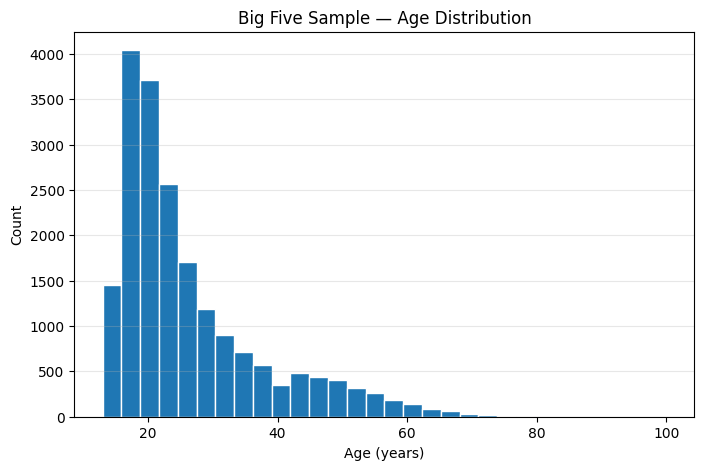


已存檔：C:\irene_python\week10_projects\big5-mini-explorer\reports\age_distribution_style_c.png
檔案大小：30.3 KB


In [5]:
# 5. Plot + Save
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(age_clean, bins=30, edgecolor="white")
ax.set_title("Big Five Sample — Age Distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)

# bbox_inches='tight' 避免 title/label 被裁掉；dpi=150 在報告中夠清晰
fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n已存檔：{OUTPUT_PATH}")
print(f"檔案大小：{OUTPUT_PATH.stat().st_size / 1024:.1f} KB")

## 小結

- 已產出 `reports/age_distribution_style_c.png`。
- 過濾掉 `age < 10` 或 `> 100` 的離群值，避免極端值壓縮 x 軸。
- 後續可以延伸：
  - 依 `gender` 分群比較（overlay 或 stacked histogram）
  - 依 `country` 看主要受試者來源
  - 與五大人格分數的相關性